In [4]:
# breast_cancer_pipeline.py
# Full reproducible pipeline for Wisconsin Breast Cancer dataset
# Assumes dataset is at /mnt/data/data.csv. Change DATA_PATH if needed.

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = r"C:\Users\Noor Mustafa Chohan\Documents\PROJECTS\Wisconsin Breast Cancer\data.csv"  # change if running locally

In [5]:
# ---------- 1. Load dataset ----------
print("Loading dataset from:", DATA_PATH)
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

# Heuristic for target column (common names)
if 'diagnosis' in df.columns:
    target_col = 'diagnosis'
elif 'target' in df.columns:
    target_col = 'target'
elif 'label' in df.columns:
    target_col = 'label'
else:
    target_col = df.columns[-1]  # fallback to last column

print("Using target column:", target_col)

Loading dataset from: C:\Users\Noor Mustafa Chohan\Documents\PROJECTS\Wisconsin Breast Cancer\data.csv
Dataset shape: (569, 33)
Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']
Using target column: diagnosis


In [6]:
# ---------- 2. Prepare features and target ----------
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# Drop ID-like or unique columns
drop_cols = []
for c in X.columns:
    if c.lower() == 'id' or X[c].nunique() == len(X):
        drop_cols.append(c)
if drop_cols:
    print("Dropping ID/unique columns:", drop_cols)
    X = X.drop(columns=drop_cols)

# Convert all columns to numeric where possible (coerce non-numeric -> NaN)
for c in X.columns:
    X[c] = pd.to_numeric(X[c], errors='coerce')

# If target is non-numeric, encode
if y.dtype == object or y.dtype.name == 'category':
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    print("Label encoding applied to target. Classes:", list(le.classes_))
else:
    y_enc = y.values

Dropping ID/unique columns: ['id']
Label encoding applied to target. Classes: ['B', 'M']


In [7]:
# ---------- 3. Handle missing values ----------
# Detect columns with all NaN -> drop them
from sklearn.impute import KNNImputer

all_nan_cols = [c for c in X.columns if X[c].isna().all()]
if all_nan_cols:
    print("Dropping all-NaN columns:", all_nan_cols)
    X = X.drop(columns=all_nan_cols)

# Drop columns with zero variance (constant)
const_cols = [c for c in X.columns if X[c].nunique() <= 1]
if const_cols:
    print("Dropping constant columns:", const_cols)
    X = X.drop(columns=const_cols)

# Now select numeric columns (features)
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric feature count:", len(num_cols))

knn_imputer = KNNImputer(n_neighbors=5)  # you can tune n_neighbors
X_knn = knn_imputer.fit_transform(X[num_cols])
X_imputed = pd.DataFrame(X_knn, columns=num_cols, index=X.index)

# If there are non-numeric columns (unlikely), encode them (simple)
non_num_cols = [c for c in X.columns if c not in num_cols]
if non_num_cols:
    print("Non-numeric columns detected (will be label-encoded):", non_num_cols)
    for c in non_num_cols:
        X[c] = X[c].astype(str).fillna("NA")
        X_imputed[c] = LabelEncoder().fit_transform(X[c])

Dropping all-NaN columns: ['Unnamed: 32']
Numeric feature count: 30


In [8]:
# ---------- 4. Scaling ----------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

X_model = pd.DataFrame(X_scaled, columns=X_imputed.columns, index=X_imputed.index)


In [9]:

# ---------- 5. Train/test split ----------
X_train, X_test, y_train, y_test = train_test_split(X_model, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (455, 30) Test shape: (114, 30)


In [10]:
# ---------- 6. Define base models ----------
models = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'GaussianNB': GaussianNB(),
    'MLP': MLPClassifier(max_iter=500, random_state=42)
}

In [11]:
# ---------- 6. Define base models ----------
models = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),  # recommended
    'GaussianNB': GaussianNB(),
    'MLP': MLPClassifier(max_iter=500, random_state=42)
}

In [12]:
# ---------- 7. Hyperparameter tuning for RF and SVM ----------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# RandomForest grid search
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}
print("Tuning RandomForest (GridSearchCV)...")
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=cv, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print("Best RF params:", rf_grid.best_params_)

# SVM grid search (RBF)
svm_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}
print("Tuning SVM (GridSearchCV)...")
svm_grid = GridSearchCV(SVC(kernel='rbf', probability=True, random_state=42), svm_param_grid, cv=cv, scoring='f1', n_jobs=-1)
svm_grid.fit(X_train, y_train)
best_svm = svm_grid.best_estimator_
print("Best SVM params:", svm_grid.best_params_)

# Update models dict with tuned estimators
models['RandomForest'] = best_rf
models['SVM'] = best_svm

Tuning RandomForest (GridSearchCV)...
Best RF params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Tuning SVM (GridSearchCV)...
Best SVM params: {'C': 10, 'gamma': 'scale'}



Training: DecisionTree
DecisionTree -> Acc: 0.9298, Prec: 0.9048, Rec: 0.9048, F1: 0.9048, AUC: 0.9246
Classification report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

Confusion matrix:
 [[68  4]
 [ 4 38]]

Training: RandomForest
RandomForest -> Acc: 0.9737, Prec: 1.0000, Rec: 0.9286, F1: 0.9630, AUC: 0.9950
Classification report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion matrix:
 [[72  0]
 [ 3 39]]

Training: SVM
S

  File "C:\Users\Noor Mustafa Chohan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Noor Mustafa Chohan\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Noor Mustafa Chohan\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File

KNN -> Acc: 0.9561, Prec: 0.9744, Rec: 0.9048, F1: 0.9383, AUC: 0.9816
Classification report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion matrix:
 [[71  1]
 [ 4 38]]

Training: GaussianNB
GaussianNB -> Acc: 0.9211, Prec: 0.9231, Rec: 0.8571, F1: 0.8889, AUC: 0.9891
Classification report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        72
           1       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114

Confusion matrix:
 [[69  3]
 [ 6 36]]

Training: MLP
MLP -> Acc: 0.9649, Prec: 1.0000, Rec:

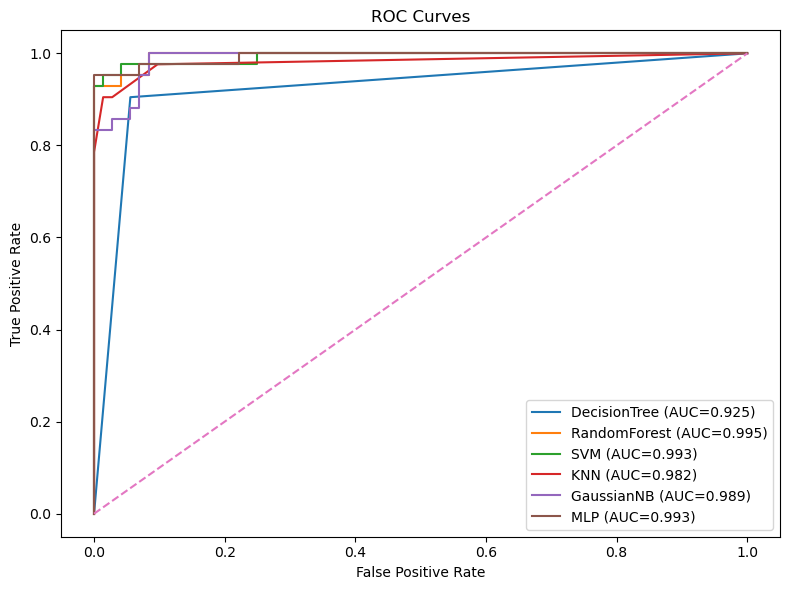

In [13]:
 #---------- 8. Train all models and evaluate ----------
results = []
plt.figure(figsize=(8,6))
for name, model in models.items():
    print("\nTraining:", name)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    # obtain scores for ROC/AUC
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        try:
            y_scores = model.decision_function(X_test)
        except Exception:
            y_scores = y_pred  # fallback
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_test, y_scores)
    except Exception:
        auc = float('nan')
    print(f"{name} -> Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
    print("Classification report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion matrix:\n", cm)
    try:
        fpr, tpr, _ = roc_curve(y_test, y_scores)
        plt.plot(fpr, tpr, label=f"{name} (AUC={np.round(auc,3)})")
    except Exception as e:
        print("ROC skipped for", name, e)
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': auc})

plt.plot([0,1], [0,1], linestyle='--')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()



In [14]:
# ---------- 9. Select best model based on F1-score ----------
results_df = pd.DataFrame(results)
best_model_name = results_df.loc[results_df['F1'].idxmax(), 'Model']
print("\nBest model based on F1-score:", best_model_name)

# Retrieve the model object
best_model = models[best_model_name]

# ---------- 10. Save model, scaler, and label encoder ----------
import joblib

joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

try:
    joblib.dump(le, "label_encoder.pkl")
except:
    print("Label encoder not found — skipped saving it.")

print("\nModel saved successfully as best_model.pkl")
print("Scaler saved as scaler.pkl")



Best model based on F1-score: RandomForest

Model saved successfully as best_model.pkl
Scaler saved as scaler.pkl


In [15]:
# ---------- 9. Feature importances ----------
if hasattr(best_rf, 'feature_importances_'):
    fi = pd.DataFrame({'feature': X_model.columns, 'importance': best_rf.feature_importances_}).sort_values('importance', ascending=False)
    print("\nTop 10 RandomForest feature importances:")
    print(fi.head(10).to_string(index=False))

# Decision tree feature importances if available
dt = models.get('DecisionTree')
if dt is not None and hasattr(dt, 'feature_importances_'):
    dfi = pd.DataFrame({'feature': X_model.columns, 'importance': dt.feature_importances_}).sort_values('importance', ascending=False)
    print("\nDecisionTree top features:")
    print(dfi.head(10).to_string(index=False))

# ---------- 10. Save results and models ----------
results_df = pd.DataFrame(results).sort_values(by='F1', ascending=False)
out_dir = '/mnt/data' if os.path.isdir('/mnt/data') else os.getcwd()
results_csv = os.path.join(out_dir, 'model_results.csv')
results_df.to_csv(results_csv, index=False)
print("\nSaved results to:", results_csv)

# Save best models (RF and SVM)
rf_path = os.path.join(out_dir, 'best_random_forest.joblib')
svm_path = os.path.join(out_dir, 'best_svm.joblib')
joblib.dump(best_rf, rf_path)
joblib.dump(best_svm, svm_path)
print("Saved best RandomForest ->", rf_path)
print("Saved best SVM ->", svm_path)


Top 10 RandomForest feature importances:
             feature  importance
          area_worst    0.152915
concave points_worst    0.134546
        radius_worst    0.100371
     perimeter_worst    0.087629
 concave points_mean    0.083709
      perimeter_mean    0.077532
         radius_mean    0.059437
      concavity_mean    0.051643
           area_mean    0.044947
     concavity_worst    0.030722

DecisionTree top features:
             feature  importance
     perimeter_worst    0.727477
concave points_worst    0.078970
    smoothness_worst    0.040833
        texture_mean    0.037871
       texture_worst    0.022545
           area_mean    0.022452
        radius_worst    0.017530
          area_worst    0.015606
 concave points_mean    0.013416
        concavity_se    0.007043

Saved results to: C:\Users\Noor Mustafa Chohan\Documents\PROJECTS\Wisconsin Breast Cancer\model_results.csv
Saved best RandomForest -> C:\Users\Noor Mustafa Chohan\Documents\PROJECTS\Wisconsin Breast Can

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
import joblib

# ----------------- 1. Sample data (3 rows) -----------------
sample_data = pd.DataFrame({
    'radius_mean': [14.2, 20.5, 12.1],
    'texture_mean': [19.3, 32.1, 15.7],
    'perimeter_mean': [92.3, 135.2, 82.1],
    'area_mean': [654, 1200, 420],
    'smoothness_mean': [0.1, 0.15, 0.08],
    'compactness_mean': [0.12, 0.25, 0.08],
    'concavity_mean': [0.15, 0.3, 0.05],
    'concave points_mean': [0.1, 0.15, 0.02],
    'symmetry_mean': [0.18, 0.25, 0.15],
    'fractal_dimension_mean': [0.06, 0.08, 0.05],
    'radius_se': [0.8, 1.2, 0.5],
    'texture_se': [1.2, 2.5, 0.8],
    'perimeter_se': [5.2, 8.5, 4.1],
    'area_se': [40, 120, 25],
    'smoothness_se': [0.005, 0.015, 0.004],
    'compactness_se': [0.02, 0.05, 0.01],
    'concavity_se': [0.03, 0.08, 0.005],
    'concave points_se': [0.01, 0.03, 0.002],
    'symmetry_se': [0.02, 0.05, 0.01],
    'fractal_dimension_se': [0.005, 0.01, 0.003],
    'radius_worst': [16.5, 25.2, 13.0],
    'texture_worst': [24.3, 40.2, 18.5],
    'perimeter_worst': [110, 180, 95],
    'area_worst': [900, 2500, 550],
    'smoothness_worst': [0.12, 0.18, 0.09],
    'compactness_worst': [0.2, 0.35, 0.1],
    'concavity_worst': [0.25, 0.4, 0.08],
    'concave points_worst': [0.12, 0.25, 0.05],
    'symmetry_worst': [0.22, 0.35, 0.18],
    'fractal_dimension_worst': [0.08, 0.15, 0.06]
})

In [17]:
# sample_data: your new 3 rows
from sklearn.impute import KNNImputer

# 1. Impute missing values (if any)
knn_imputer = KNNImputer(n_neighbors=5)
sample_knn = knn_imputer.fit_transform(sample_data)
sample_imputed = pd.DataFrame(sample_knn, columns=sample_data.columns)

# 2. Scale features using the scaler already fitted during training
sample_scaled = scaler.transform(sample_imputed)  # use in-memory 'scaler'

# 3. Predict using models already trained in this session
rf_pred = best_rf.predict(sample_scaled)
svm_pred = best_svm.predict(sample_scaled)

rf_proba = best_rf.predict_proba(sample_scaled)[:,1]
svm_proba = best_svm.predict_proba(sample_scaled)[:,1]

print("RandomForest predictions:", rf_pred)
print("RandomForest probabilities:", rf_proba)
print("SVM predictions:", svm_pred)
print("SVM probabilities:", svm_proba)


RandomForest predictions: [0 1 0]
RandomForest probabilities: [0.36840003 0.99664773 0.04162557]
SVM predictions: [1 1 0]
SVM probabilities: [0.96037589 0.85055699 0.00724166]


--⃣ Look at the predictions --
For your 3 new samples:
Sample	RF Prediction	RF Prob	SVM Prediction	SVM Prob
1	0 (Benign)	0.368	1 (Malignant)	0.960
2	1 (Malignant)	0.997	1 (Malignant)	0.851
3	0 (Benign)	0.042	0 (Benign)	0.007

Samples 2 & 3: Both models agree with high probability → model is clearly confident. ✅
Sample 1: Models disagree — RandomForest predicts Benign, SVM predicts Malignant, and probabilities differ (RF: 37%, SVM: 96%). ⚠

--Model performance on truly unseen data is probabilistic:--
Sometimes models disagree if the sample is close to the boundary between classes.
This is normal, especially with only 3 samples — small test sets can show variance.

--Confidence matters:--
SVM is very confident about the first sample being Malignant.
RF is less confident about it being Benign.
In practice, the probability score helps you decide: high confidence predictions are more trustworthy.